# Spatial Cross-Validated GraphSAGE – Multi-Threshold Accessibility Index

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

import matplotlib.pyplot as plt

In [2]:
# CONFIG
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

N_CLUSTERS = 5
RANDOM_STATE = 42
TARGET_COLS = ["jobs_15min", "jobs_30min", "jobs_45min", "jobs_60min"]

weights = np.array([1.0, 0.7, 0.4, 0.2])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# LOAD DATA
X_df = pd.read_parquet("../data/processed_predictors/atlanta_2023_predictor_dataset.parquet")
y_df = pd.read_parquet("../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet")

In [4]:
# COMPOSITE TARGET
y_df["access_index"] = (
    np.log1p(y_df[TARGET_COLS]) * weights
).sum(axis=1)

In [5]:
# LOAD GEOMETRY
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

In [6]:
# MERGE
df = X_df.merge(y_df[["from_id"] + TARGET_COLS + ["access_index"]],
                left_on="tract_id",
                right_on="from_id",
                how="inner")

gdf = df.merge(tracts[["tract_id", "geometry"]],
               on="tract_id",
               how="inner")

gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=tracts.crs)

In [7]:
# PROJECT
gdf = gdf.to_crs(epsg=5070)

# %%
# CENTROIDS (FIX ORDERING)
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

In [8]:
# SPATIAL CLUSTERS
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")
gdf["cluster"] = kmeans.fit_predict(coords)

In [9]:
# FEATURE COLUMNS
drop_cols = [
    "tract_id", "from_id", "geometry", "centroid", "x", "y", "cluster",
    "access_index"
] + TARGET_COLS

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X_base = gdf[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y_base = gdf["access_index"].values

num_nodes = len(gdf)

In [10]:
# GRAPH EDGES (simple adjacency via touches)
def build_edges(gdf):
    sindex = gdf.sindex
    edges = []

    for i, geom in enumerate(gdf.geometry):
        candidates = list(sindex.intersection(geom.bounds))
        for j in candidates:
            if i != j and gdf.geometry.iloc[i].touches(gdf.geometry.iloc[j]):
                edges.append((i, j))

    return torch.tensor(edges, dtype=torch.long).t().contiguous()

edge_index = build_edges(gdf)

In [11]:
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import torch

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden=64, heads=4):
        super().__init__()

        self.gat1 = GATConv(in_channels, hidden, heads=heads, dropout=0.2)
        self.gat2 = GATConv(hidden * heads, hidden, heads=1, dropout=0.2)

        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        return self.lin(x).squeeze()

In [12]:
# STORAGE
results = []
all_preds = []

In [13]:
# SPATIAL CV LOOP
for fold in range(N_CLUSTERS):

    print(f"\nFOLD {fold}")

    train_mask = gdf["cluster"] != fold
    test_mask = gdf["cluster"] == fold

    # SCALE PER FOLD (important fix)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_base[train_mask])
    X_test = scaler.transform(X_base[test_mask])

    X = torch.tensor(np.vstack([X_train, X_test]), dtype=torch.float)

    # reorder indices consistent with masks
    train_idx = np.where(train_mask)[0]
    test_idx = np.where(test_mask)[0]

    # y
    y = torch.tensor(y_base, dtype=torch.float)

    data = Data(x=X, edge_index=edge_index, y=y).to(device)

    train_mask_t = torch.zeros(num_nodes, dtype=torch.bool, device=device)
    test_mask_t = torch.zeros(num_nodes, dtype=torch.bool, device=device)

    train_mask_t[train_idx] = True
    test_mask_t[test_idx] = True

    data.train_mask = train_mask_t
    data.test_mask = test_mask_t

    model = GAT(X.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    loss_fn = torch.nn.MSELoss()

    # TRAIN
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

    # PREDICT
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).cpu().numpy()

    y_true = y_base[test_mask]
    y_pred = pred[test_mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append({
        "fold": fold,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    all_preds.append(pd.DataFrame({
        "tract_id": gdf.loc[test_mask, "tract_id"].values,
        "fold": fold,
        "actual": y_true,
        "predicted": y_pred
    }))



FOLD 0

FOLD 1

FOLD 2

FOLD 3

FOLD 4


In [14]:
# RESULTS
results_df = pd.DataFrame(results)
results_df

,fold,mae,rmse,r2
0,0,3.080986,3.869619,-0.625482
1,1,4.159873,4.956356,-0.214804
2,2,3.036330,3.664528,-0.104560
3,3,3.466972,4.431869,-0.708802
4,4,3.989822,4.968320,-1.340597


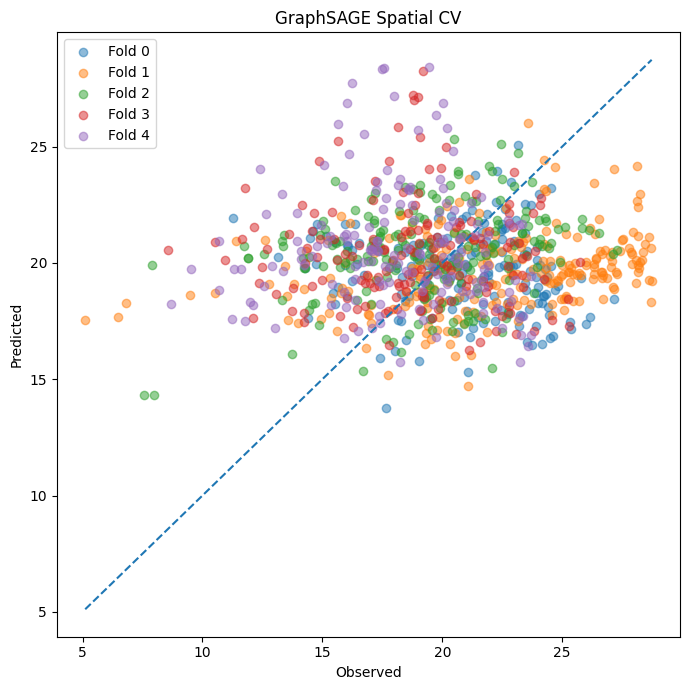

In [15]:
predictions_df = pd.concat(all_preds)

fig, ax = plt.subplots(figsize=(7,7))

for f in range(N_CLUSTERS):
    d = predictions_df[predictions_df["fold"] == f]
    ax.scatter(d["actual"], d["predicted"], alpha=0.5, label=f"Fold {f}")

min_v = min(predictions_df["actual"].min(), predictions_df["predicted"].min())
max_v = max(predictions_df["actual"].max(), predictions_df["predicted"].max())

ax.plot([min_v, max_v], [min_v, max_v], "--")

ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("GraphSAGE Spatial CV")
ax.legend()
plt.tight_layout()
plt.show()

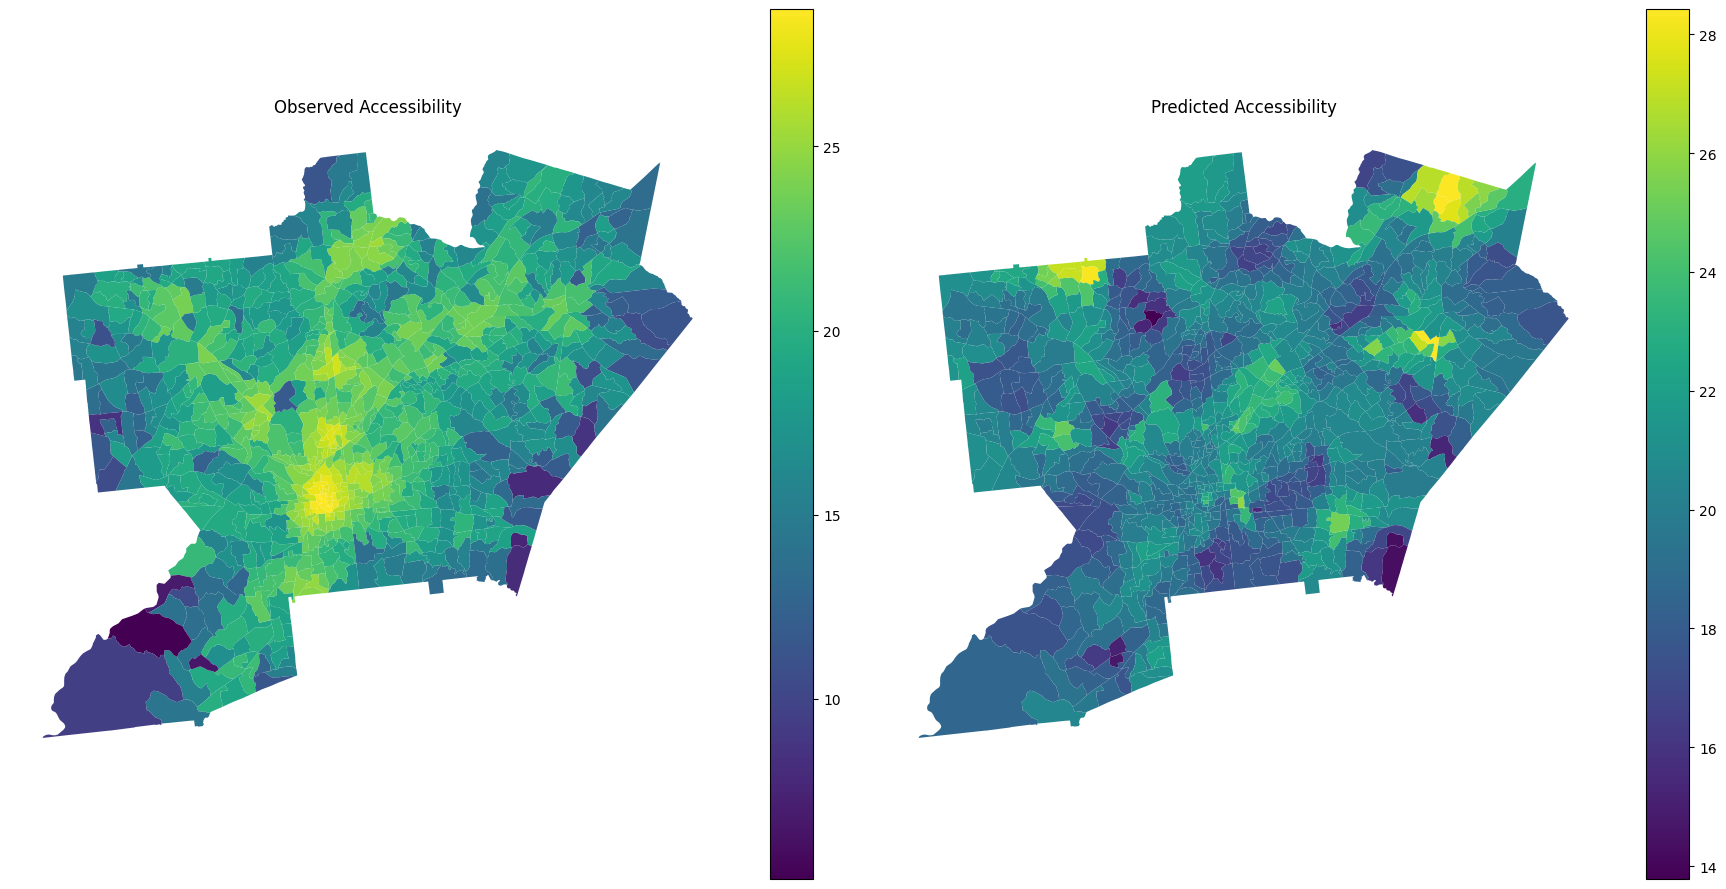

In [16]:
map_gdf = gdf[["tract_id", "geometry"]].merge(
    predictions_df.groupby("tract_id")[["actual", "predicted"]].mean(),
    on="tract_id",
    how="inner"
)

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=gdf.crs)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

map_gdf.plot(column="actual", cmap="viridis", legend=True, ax=axes[0])
axes[0].set_title("Observed Accessibility")
axes[0].axis("off")

map_gdf.plot(column="predicted", cmap="viridis", legend=True, ax=axes[1])
axes[1].set_title("Predicted Accessibility")
axes[1].axis("off")

plt.tight_layout()
plt.show()